In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ngsolve import *
from ngsolve.webgui import Draw

from pathlib import Path
import os
import sys
sys.path.append(str(Path(os.getcwd()).parent / "src"))
from scipy.signal import find_peaks, peak_widths

In [5]:
from ngsolve.webgui import Draw
import utils
import myosin_actin_gel_fem
import importlib
import matplotlib.colors as mcolors

importlib.reload(myosin_actin_gel_fem)
importlib.reload(utils)

from myosin_actin_gel_fem import MyosinActinGel2D
from utils import plot_2d_frame, animate_2d, tanh_source

In [8]:
width = 0.1

S = tanh_source(center=0.5, width=width, value=1, axis='x', interface_length=0.01)*tanh_source(center=0.5, width=0.9, value=1, axis='y', interface_length=0.1) + 0.1 
m0 = tanh_source(center=0.5, width=width, value=1, axis='x', interface_length=0.01)*tanh_source(center=0.5, width=0.9, value=1, axis='y', interface_length=0.1)
Qsq_source = tanh_source(center=0.5, width=width, value=1, axis='x', interface_length=0.01)*tanh_source(center=0.5, width=0.9, value=1, axis='y', interface_length=0.1)

In [48]:
T = 20
tau = 0.05
n_samples = 100

param_sets = [
    1.1, 1.05, 1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 
]

sim_results = [] 
for (i, Qsq) in enumerate(param_sets):
    print(f"Running simulation {i+1} with Qsq={Qsq}")

    sim = MyosinActinGel2D(
        width=1, height=1, maxh=0.03,
        
        # mechanics
        gamma = 1.0,
        eta_1 = 1,
        eta_2 = 0,
        chi0  = 0.05,
        chi1  = 0.4,
        # nematic
        kappa = 1e-3,
        beta1 = 1.0,
        beta2 = 1.0,
        Qsq   = -1 + (Qsq+1)*Qsq_source,
        # density / myosin
        S     = S,
        m0    = m0,
        k0    = 0.1,
        k1    = 0.9,
        k_m   = 1,
        n_hill = 4,
        m_ref  = 0.2,
        D_rho = 1e-4,
        D_m   = 1e-4,
        # base
        k     = 0.5,
        D     = 1e-3,
        rho0  = 1.0,
    )

    sim.simulate(
        tend=T,
        tau=tau,
        save_interval=int(0.5/tau)
    )

    filename = f'sim_data/caRhoA_{i+1}'
    data = sim.export(filename, n_samples=n_samples)
    sim_results.append(data)

Running simulation 1 with Qsq=1.1


  3%|▎         | 13/400 [00:00<00:06, 63.96it/s]

craete bilinearformapplication


100%|██████████| 400/400 [00:04<00:00, 80.52it/s]


Running simulation 2 with Qsq=1.05


...

100%|██████████| 400/400 [00:05<00:00, 78.35it/s]


Running simulation 12 with Qsq=0.55


  5%|▌         | 21/400 [00:00<00:03, 102.80it/s]

craete bilinearformapplication


100%|██████████| 400/400 [00:04<00:00, 85.10it/s]


In [49]:
inferno_80 = mcolors.ListedColormap(plt.get_cmap('inferno')(np.linspace(0, 0.7, 256)))

def plot_kymo(data, figname):
    n_mid = data['rho'].shape[2] // 2  # y-midline index

    compression = -np.gradient(data['vx'], axis=1) * n_samples

    plt.rcParams.update({'font.size': 15})
    fig, axes = plt.subplots(1, 5, figsize=(16, 6))

    fields = [
        (data['rho'][:, :, n_mid],    r'$\rho$',                        inferno_80),
        (data['m'][:, :, n_mid],      r'$m$ (myosin)',                  'viridis'),
        (data['vx'][:, :, n_mid],     r'$v_x$',                         'RdBu_r'),
        (compression[:, :, n_mid],    r'$-\partial_x v_x$',             'RdBu_r'),
        (-data['Q'][:, :, n_mid],     r'$Q_{yy}$',                      'RdBu_r'),
    ]
    t_end = data['rho'].shape[0] * 0.5

    for ax, (field, title, cmap) in zip(axes, fields):
        vmax = np.max(np.abs(field))
        vmin = -vmax if 'RdBu' in str(cmap) else 0
        im = ax.imshow(field, aspect='auto', interpolation='none',
                       origin='upper', cmap=cmap, extent=(0, 1, t_end, 0),
                       vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, location='bottom', pad=0.15,
                     ticks=[vmin, vmax], format='%.1g')
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_xticks([])

    axes[0].set_ylabel('Time')
    plt.tight_layout()
    plt.savefig(f'../figures/{figname}.svg', dpi=300)
    plt.show()

Plotting simulation 1 with Qsq=1.1


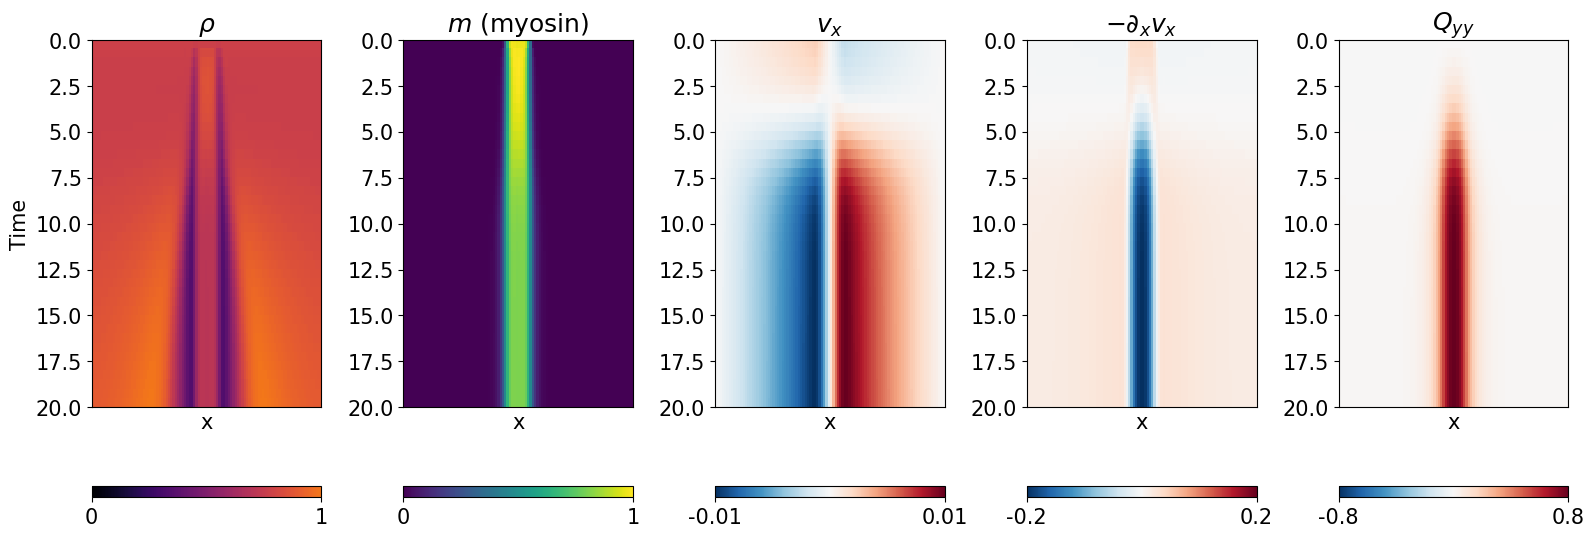

Plotting simulation 2 with Qsq=1.05


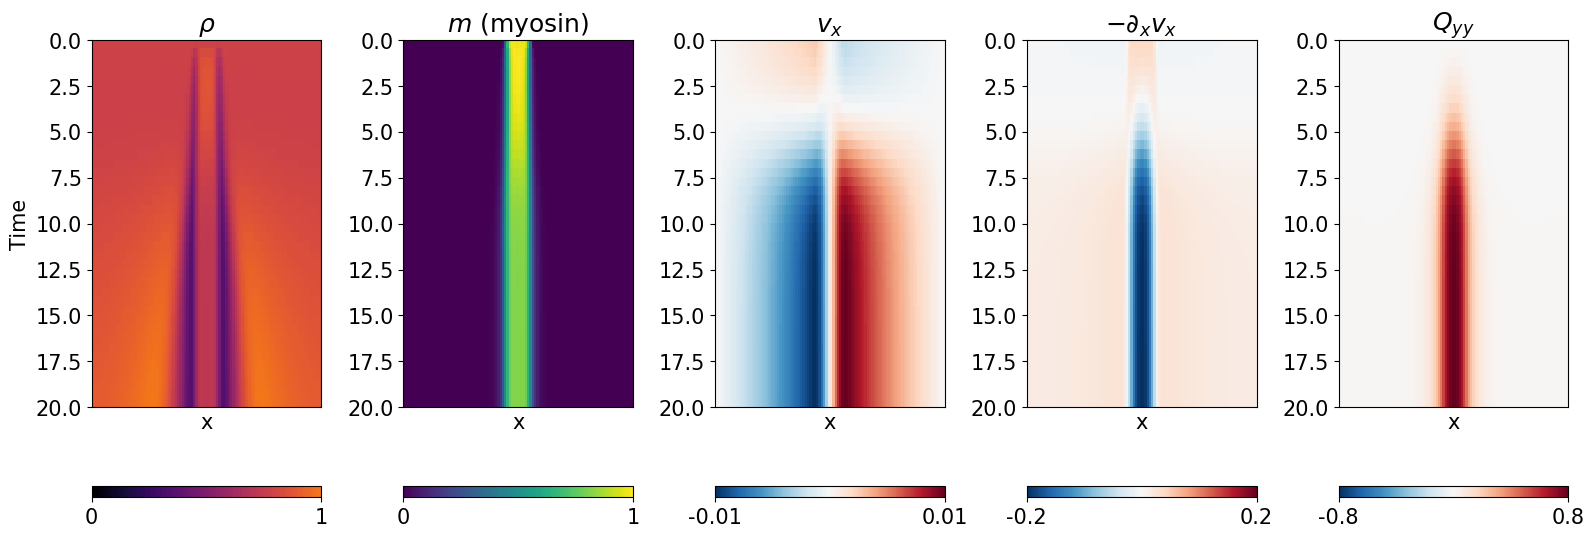

Plotting simulation 3 with Qsq=1.0


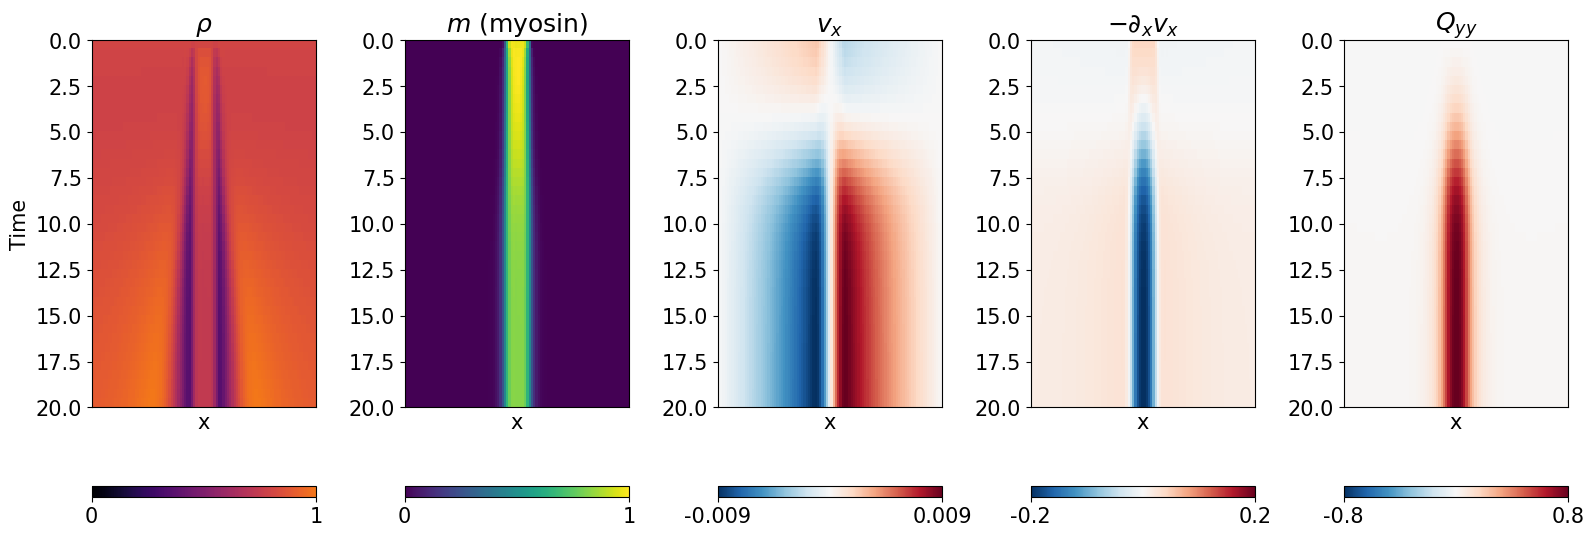

Plotting simulation 4 with Qsq=0.95


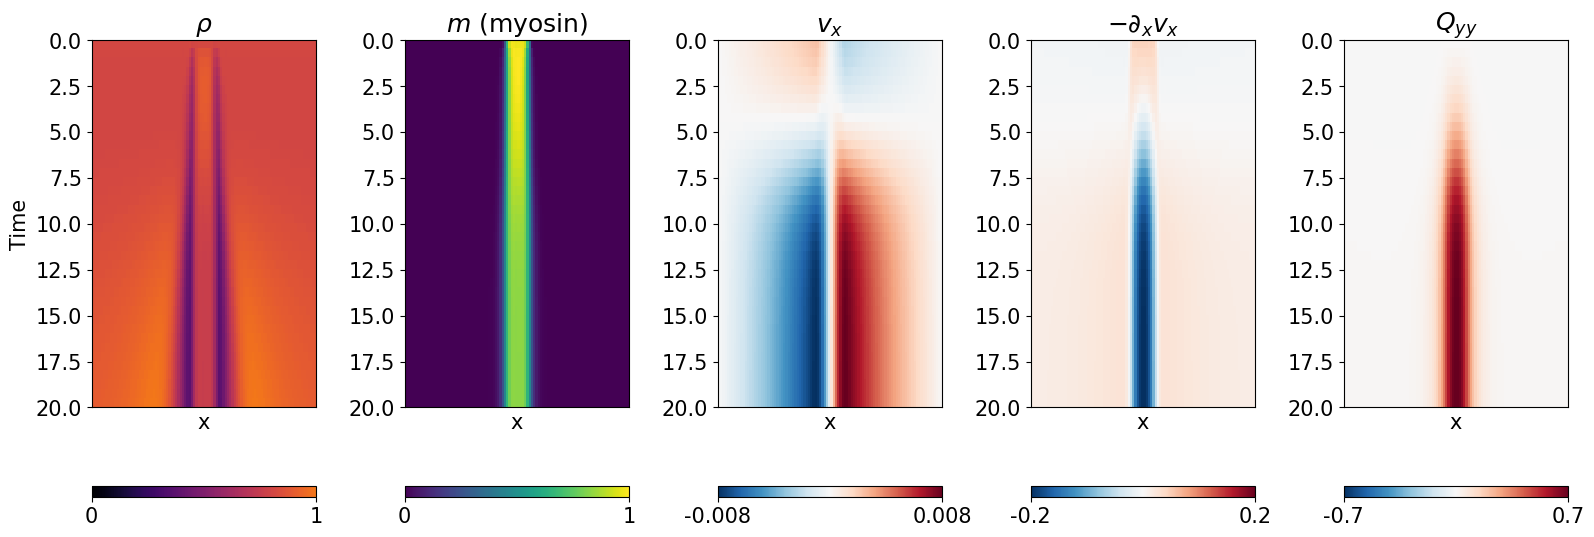

Plotting simulation 5 with Qsq=0.9


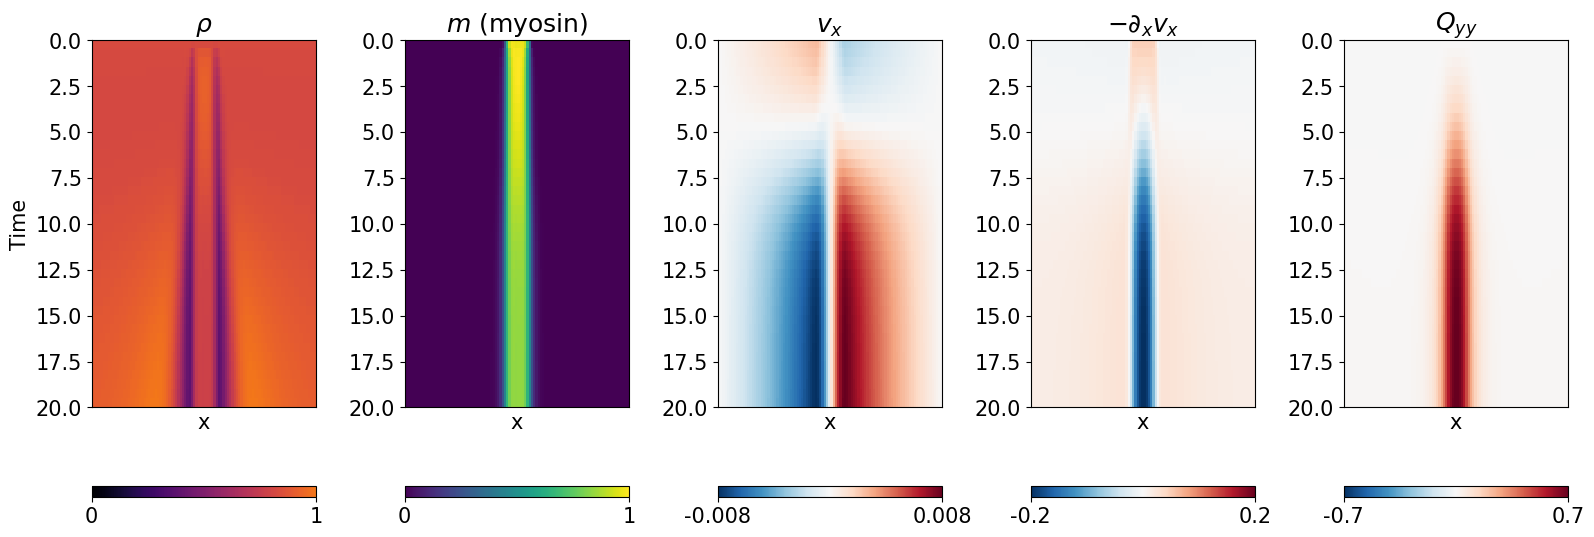

Plotting simulation 6 with Qsq=0.85


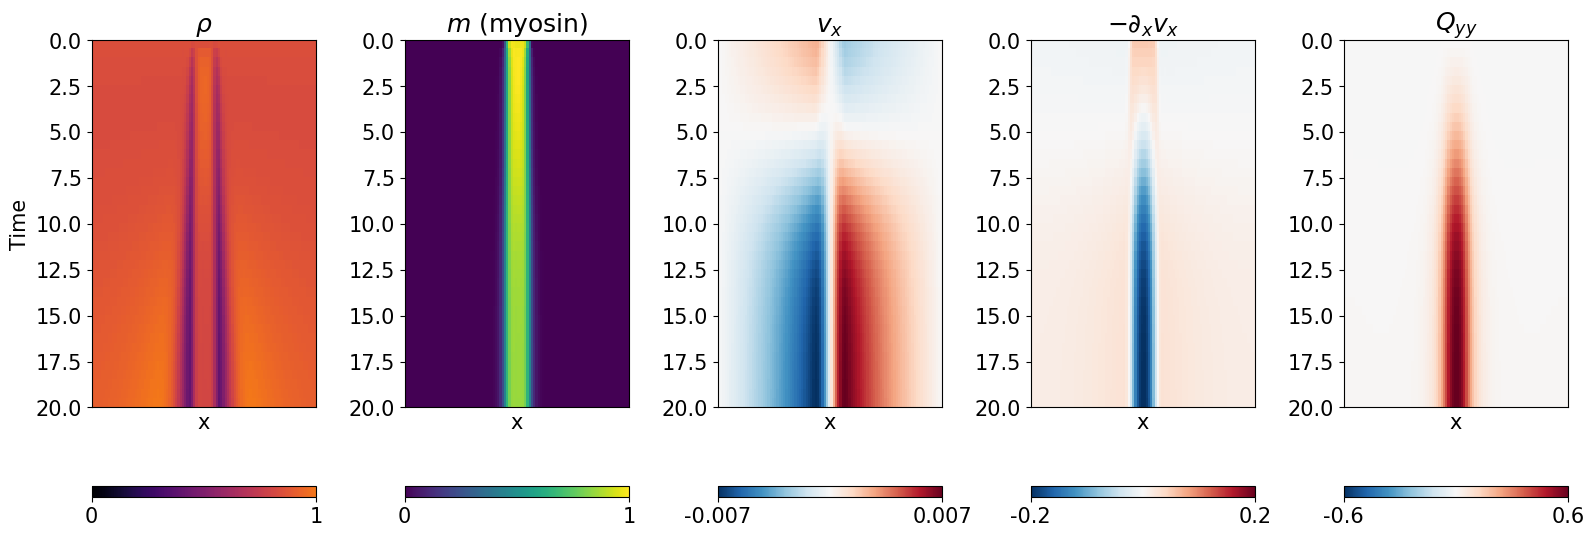

Plotting simulation 7 with Qsq=0.8


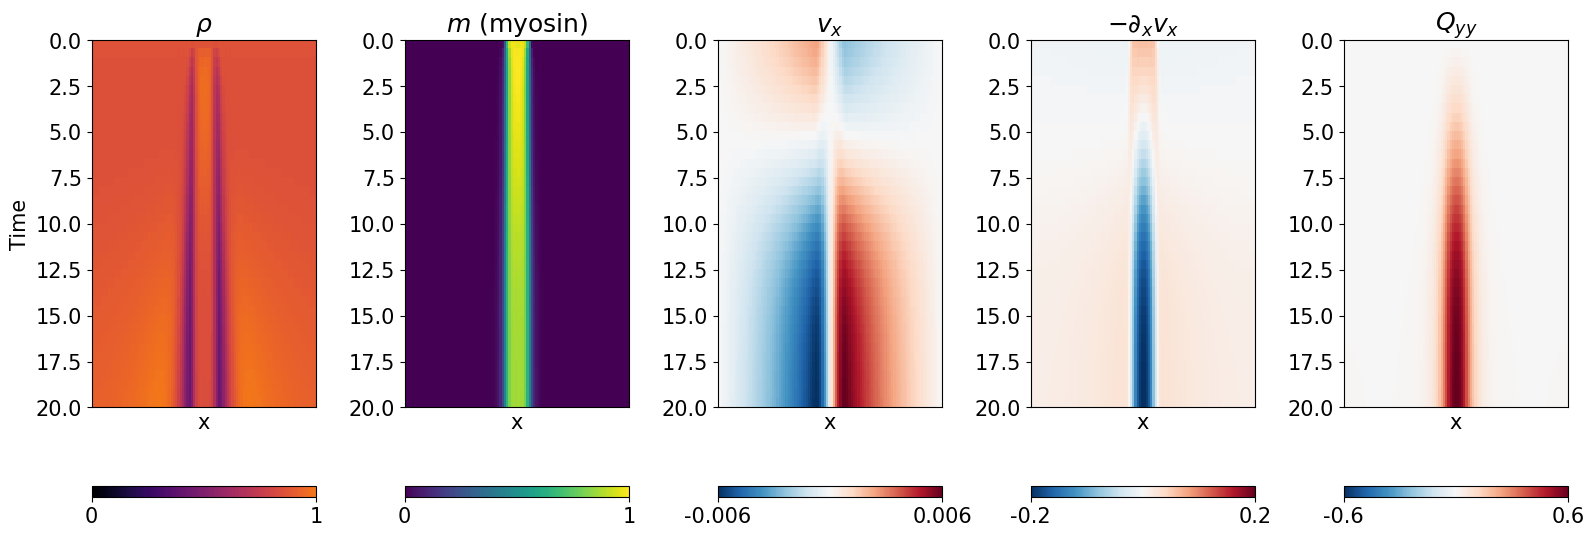

Plotting simulation 8 with Qsq=0.75


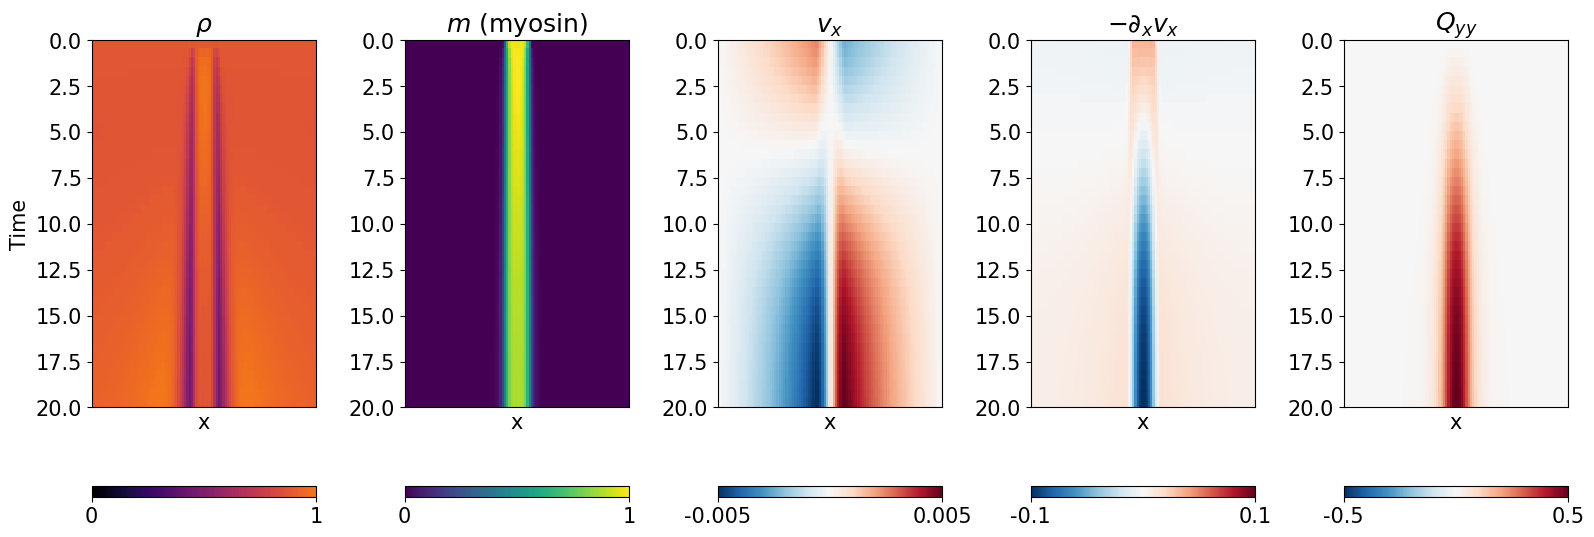

Plotting simulation 9 with Qsq=0.7


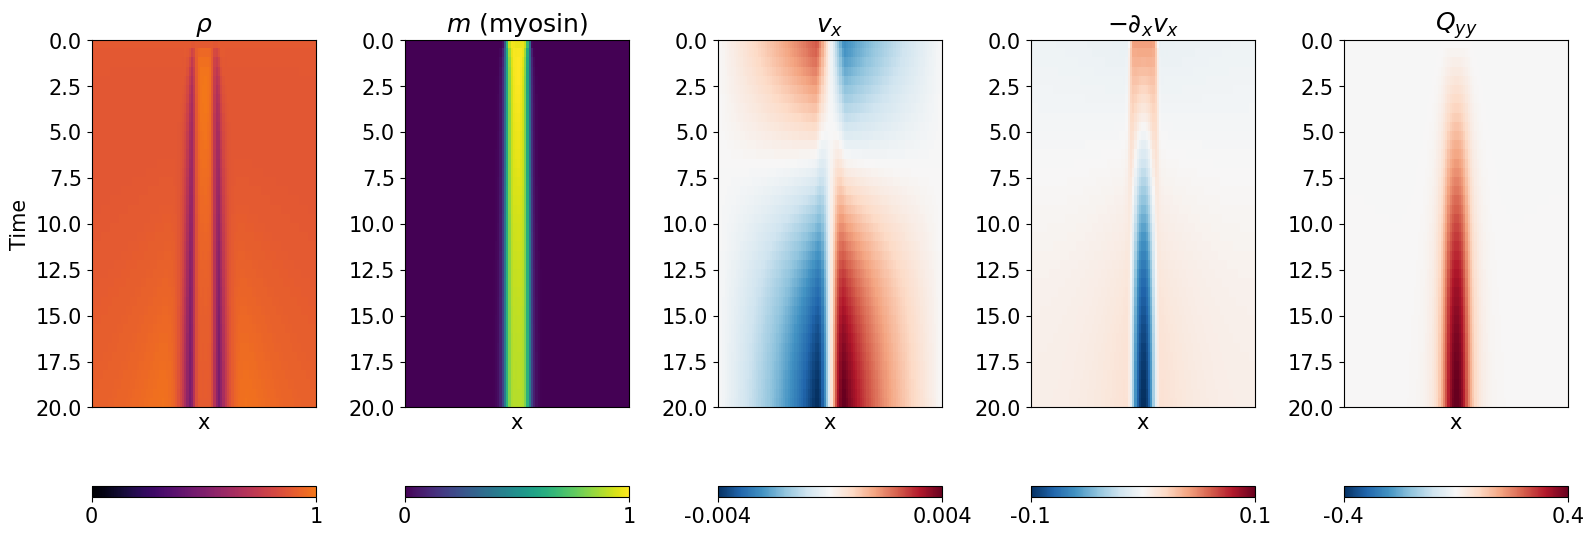

Plotting simulation 10 with Qsq=0.65


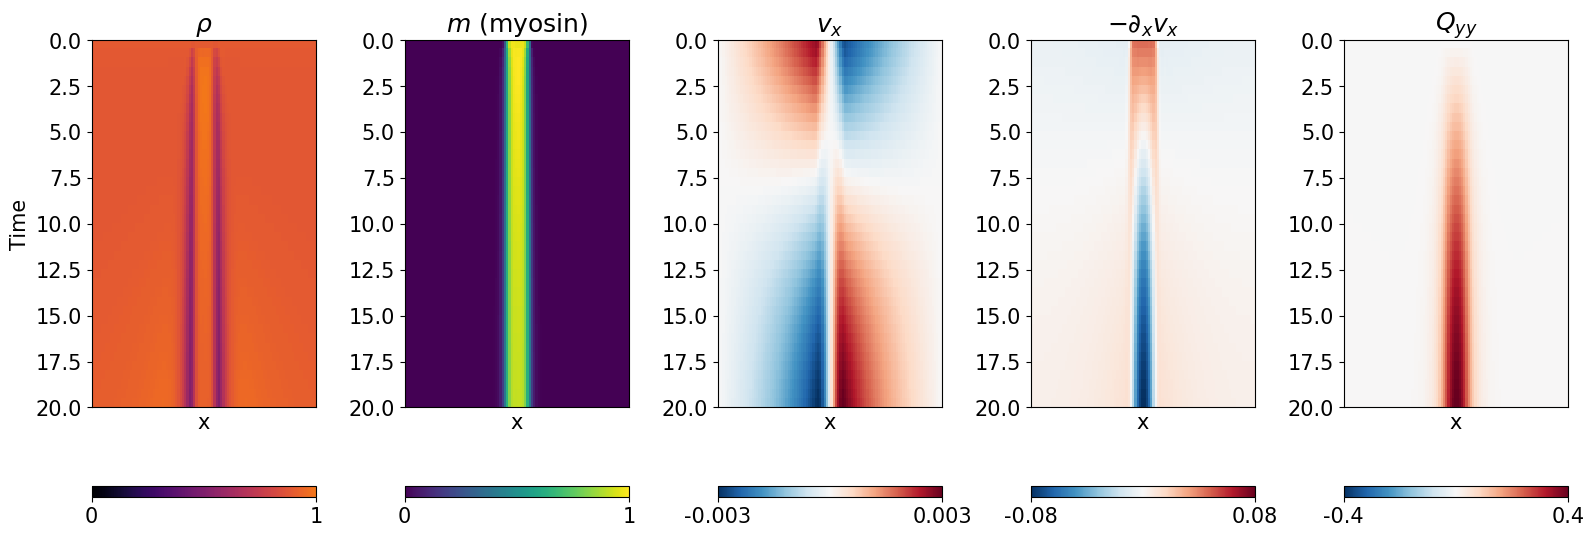

Plotting simulation 11 with Qsq=0.6


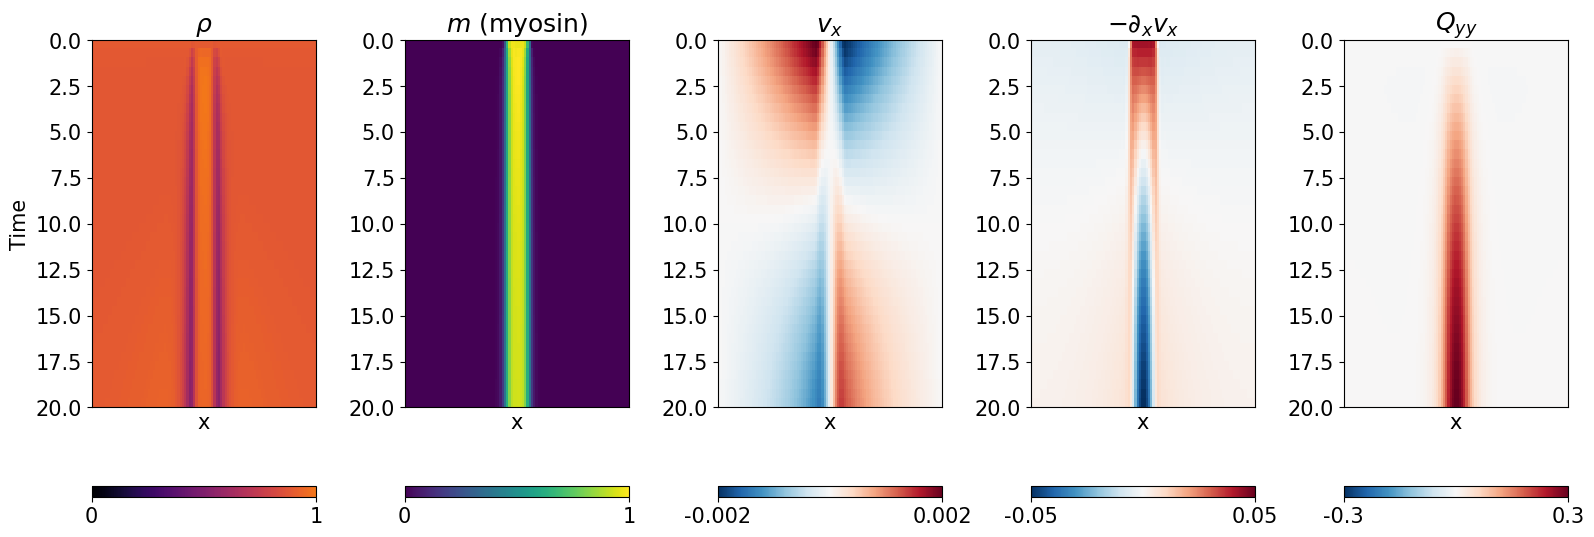

Plotting simulation 12 with Qsq=0.55


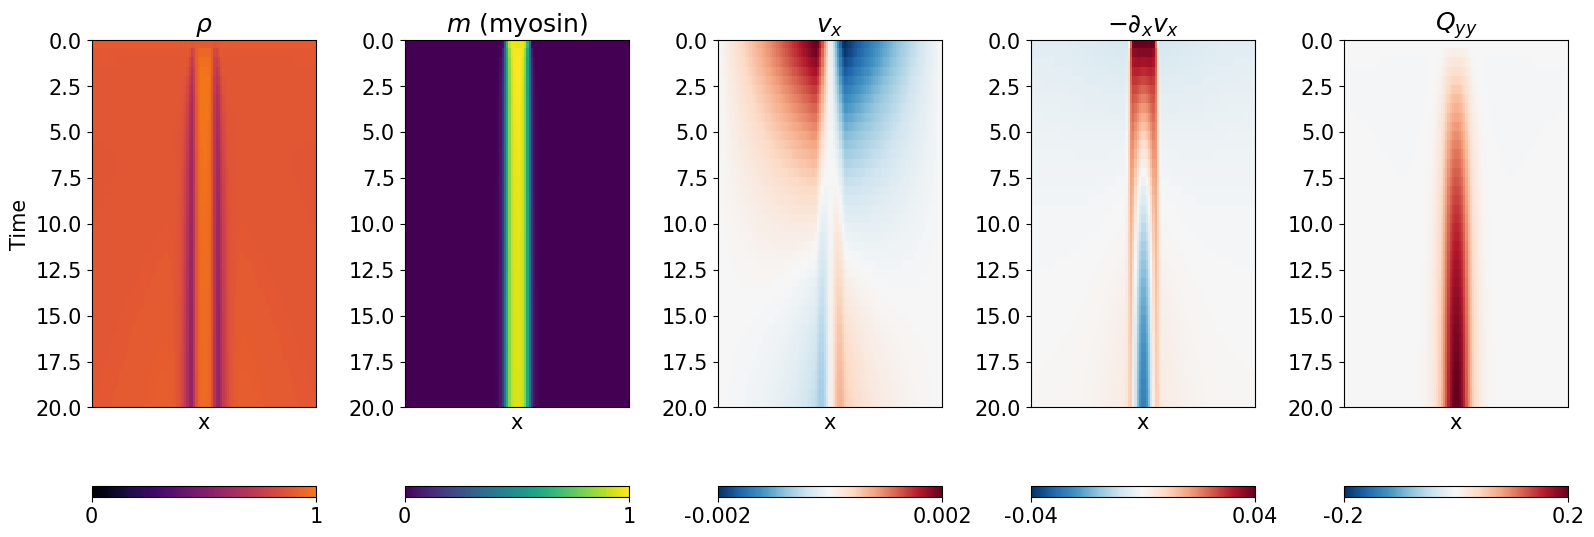

In [50]:
for (i, Qsq) in enumerate(param_sets):
    print(f"Plotting simulation {i+1} with Qsq={Qsq}")
    plot_kymo(sim_results[i], f'caRhoA_kymo_Qsq_{Qsq}')

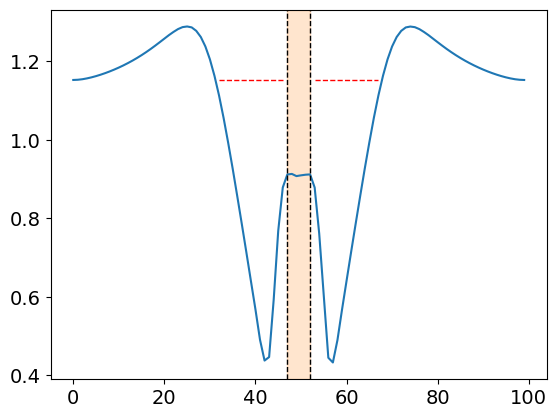

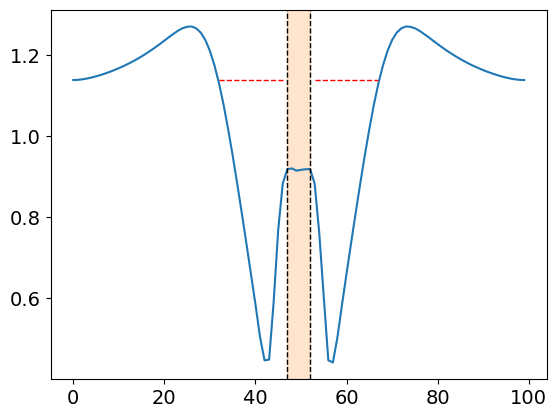

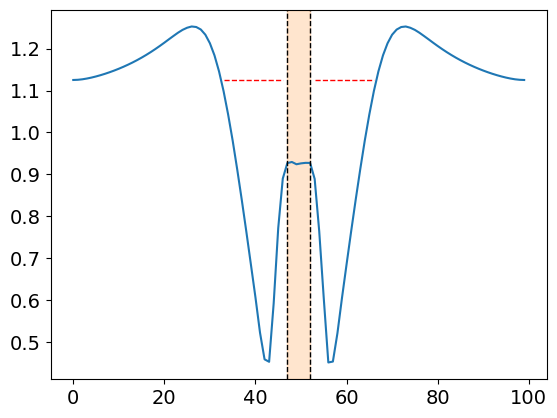

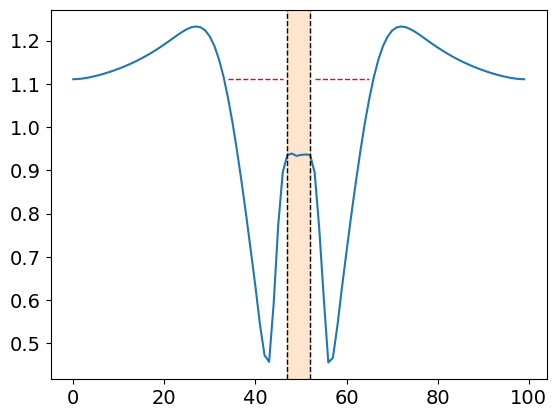

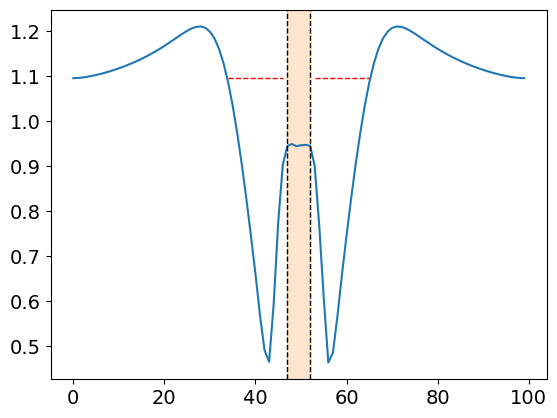

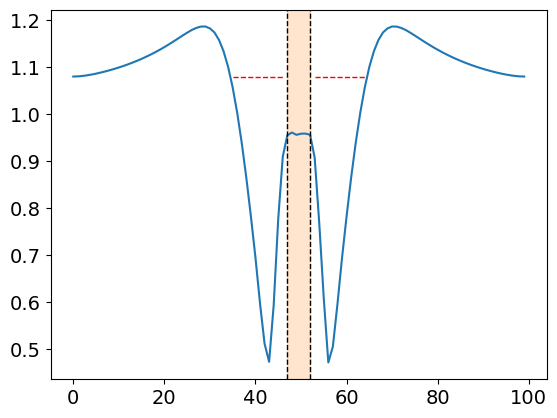

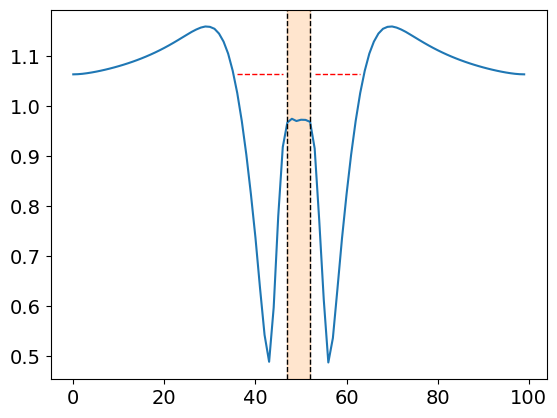

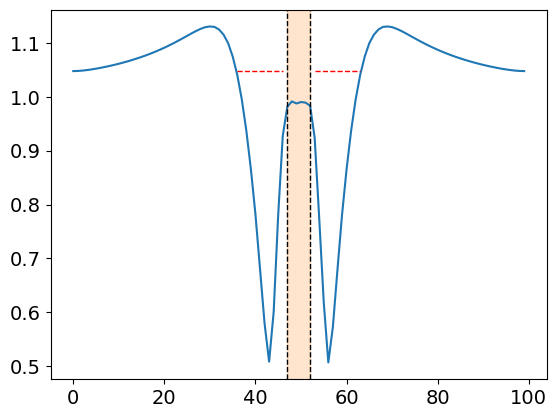

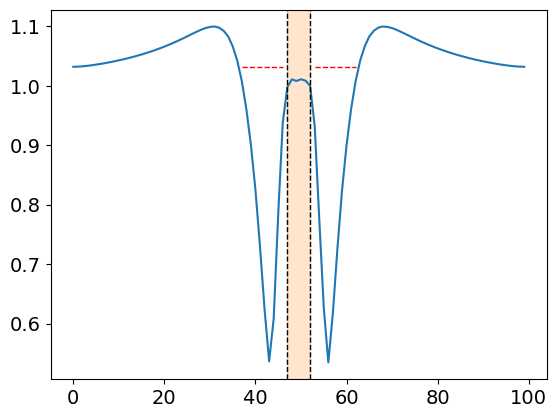

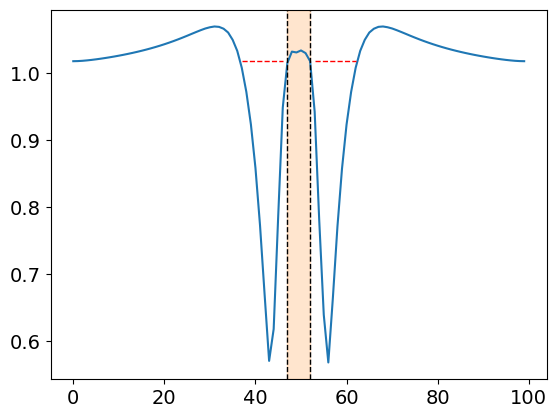

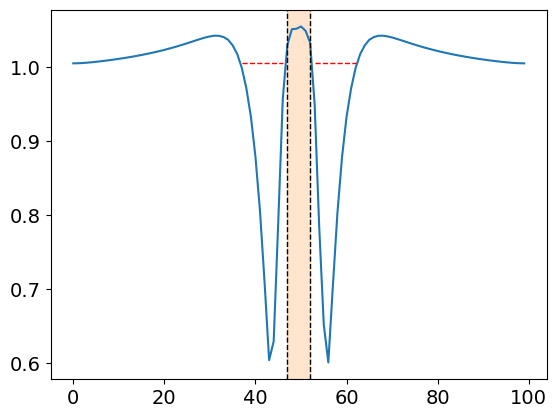

In [37]:
n_mid = n_samples // 2
n_width = 3

densities = [sim_results[i]['rho'][-1, :, n_mid] for i in range(len(param_sets))]

def compute_depletion_widths(density):
    threshold = density[0] 
    selection = density < threshold
    selection[n_mid-n_width:n_mid+n_width] = False  # Exclude the band region around the midline
    width = np.sum(selection)/2
    
    plt.plot(density)
    threshold_line = np.full(len(density), threshold)
    threshold_masked = np.ma.masked_where(~selection, threshold_line)

    
    plt.plot(threshold_masked, 'r--', linewidth=1)
    plt.axvline(x=n_mid-n_width, color='k', linestyle='--', linewidth=1)
    plt.axvline(x=n_mid-1+n_width, color='k', linestyle='--', linewidth=1)
    plt.axvspan(n_mid-n_width, n_mid-1+n_width, alpha=0.2, color='tab:orange')
    plt.show() 
    
    return width

widths = np.array([compute_depletion_widths(density) for density in densities])
velocities = np.array([np.max(np.abs(sim_results[i]['vx'][-1, :, n_mid])) for i in range(len(param_sets))])


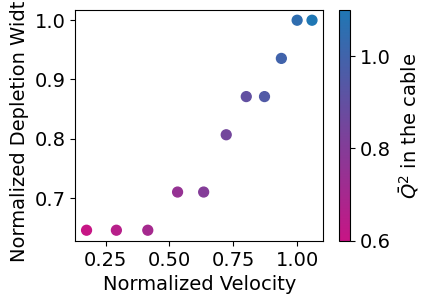

In [42]:
plt.rcParams.update({'font.size': 14})


import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def two_color_colormap(color1, color2, name="custom_cmap"):
    """
    Create a linear colormap between two colors.

    Parameters:
        color1 (str or tuple): First color (e.g., "blue" or (0.1, 0.2, 0.5)).
        color2 (str or tuple): Second color (e.g., "red" or (0.8, 0.2, 0.3)).
        name (str): Name of the colormap.

    Returns:
        LinearSegmentedColormap: A matplotlib colormap object.
    """
    return LinearSegmentedColormap.from_list(name, [color1, color2])

# Example usage
tabblue_mediumvioletred_cmap = two_color_colormap("mediumvioletred", "tab:blue")

plt.figure(figsize=(4, 3))
plt.scatter(velocities/velocities[1], widths/widths[1], c=(np.array(param_sets)), s=50, cmap=tabblue_mediumvioletred_cmap)
plt.colorbar(label=r'$\bar{Q}^2$ in the cable')
plt.xlabel('Normalized Velocity')
plt.ylabel('Normalized Depletion Width')
plt.savefig('../figures/velocity_depletion_width.svg')
plt.show()

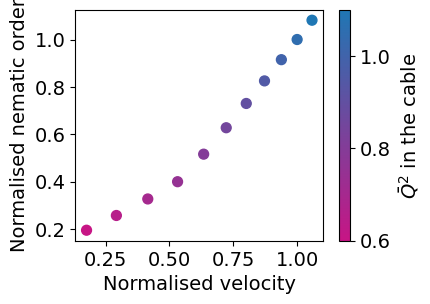

In [43]:


nematic = [np.max(np.abs(sim_results[i]['Q'][-1, 24, :])) for i in range(len(param_sets))]

plt.figure(figsize=(4, 3))
plt.scatter(velocities/velocities[1], nematic/nematic[1], c=(np.array(param_sets)), s=50, cmap=tabblue_mediumvioletred_cmap)
plt.colorbar(label=r'$\bar{Q}^2$ in the cable')
plt.ylabel('Normalised nematic order')
plt.xlabel('Normalised velocity')
plt.savefig('../figures/velocity_nematic_order.svg')
plt.show() 

In [44]:
np.savez('sim_data/caRhoA.npz', velocities=velocities/velocities[1], widths=widths/widths[1], param_sets=param_sets[1:], nematic=nematic/velocities[1])

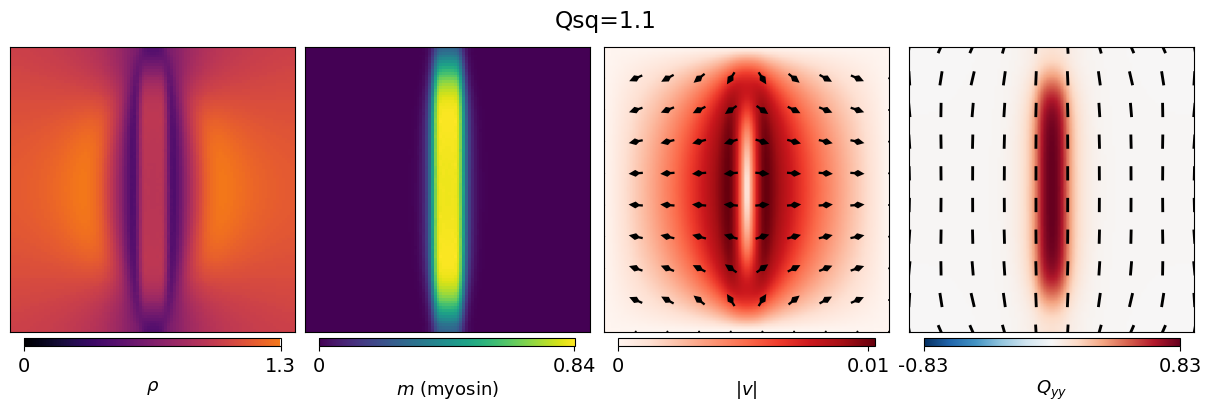

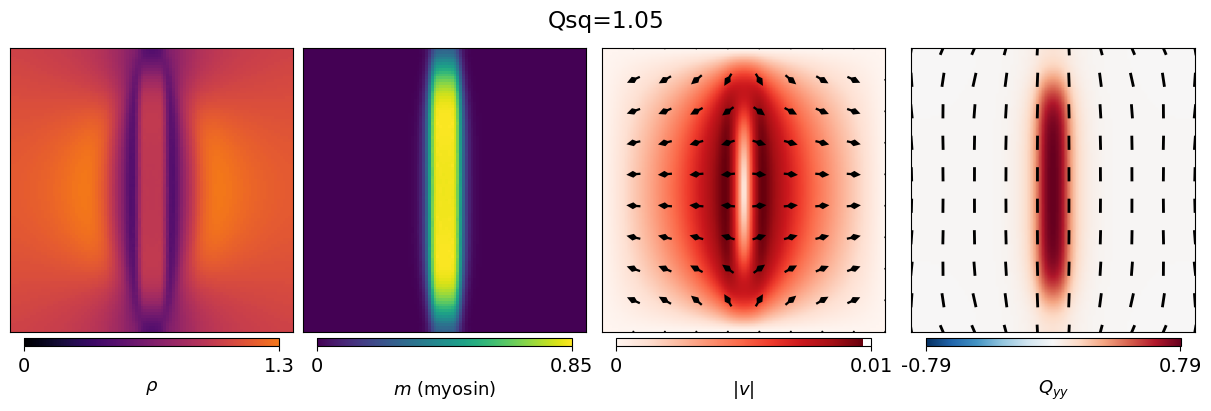

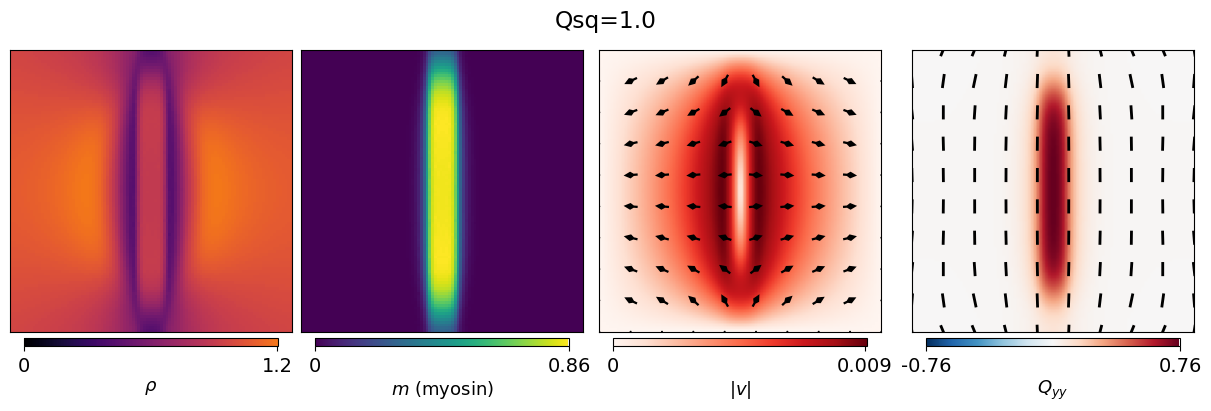

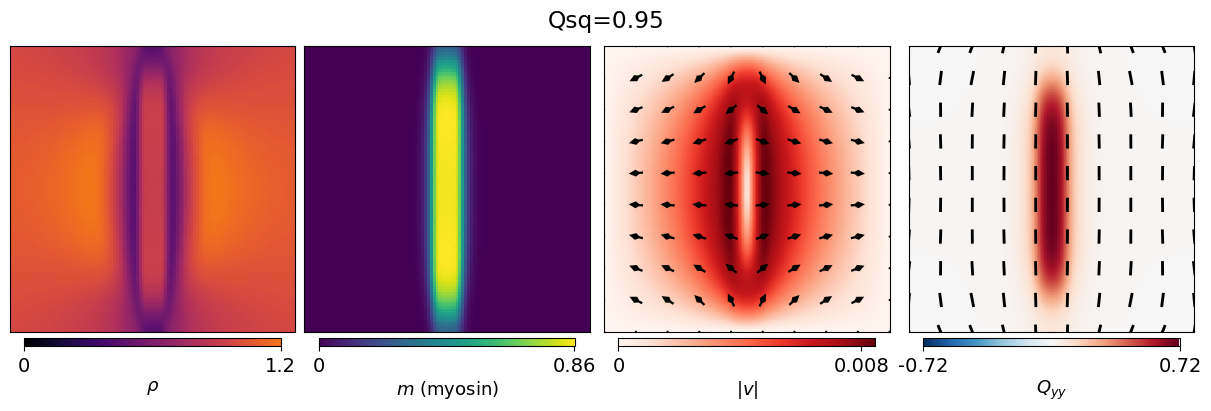

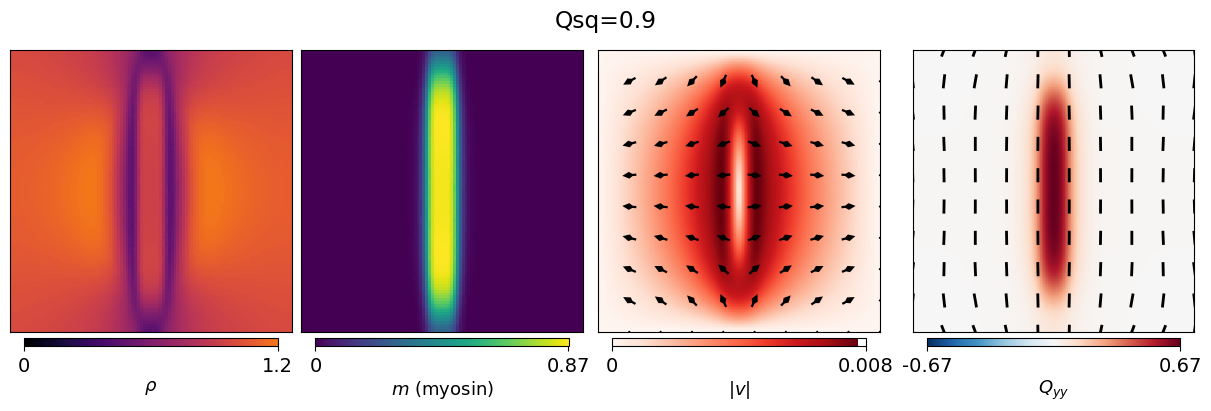

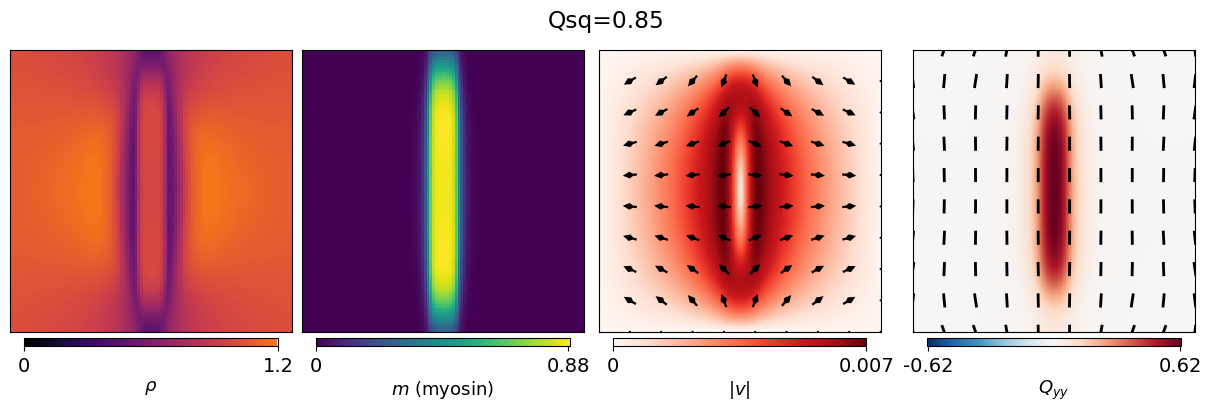

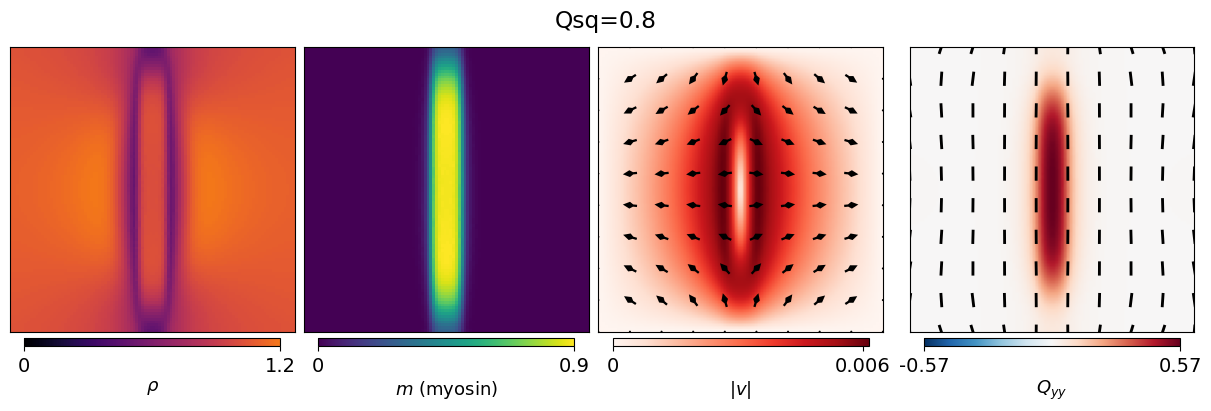

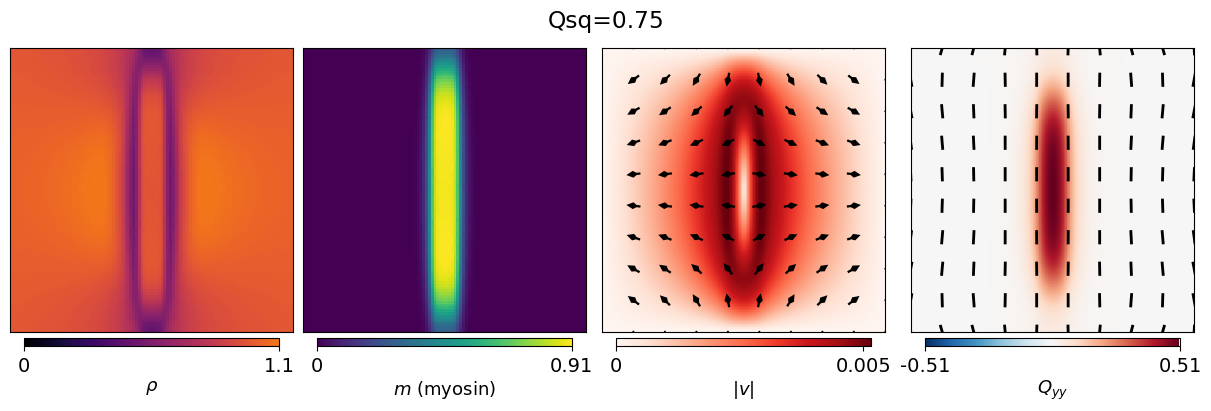

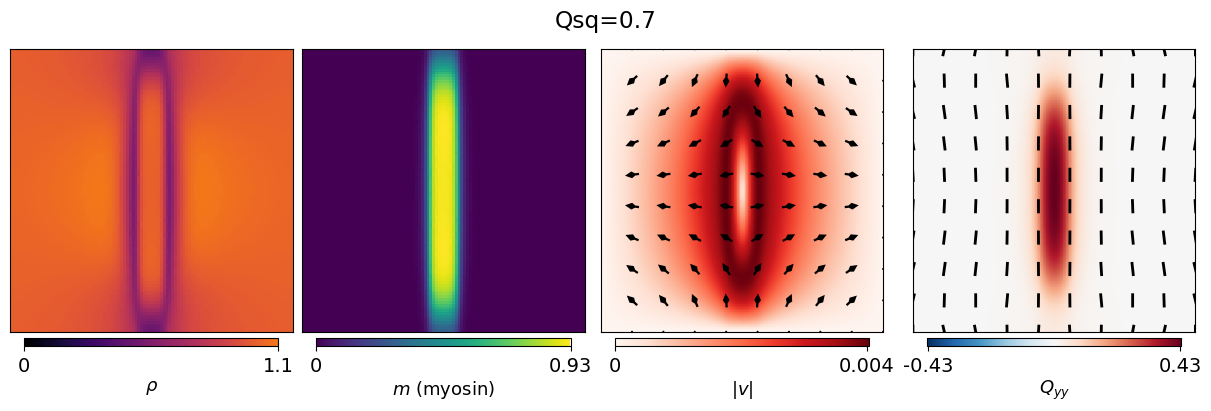

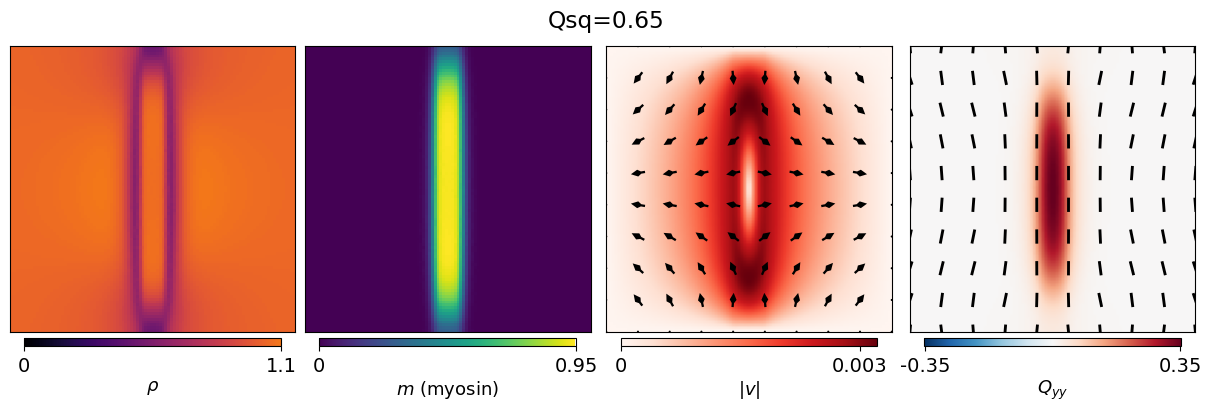

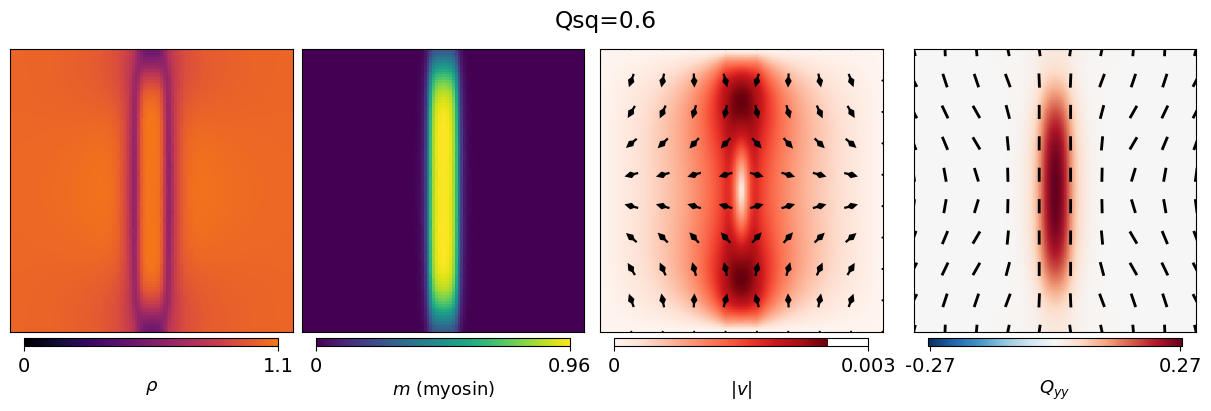

In [46]:
for i, data in enumerate(sim_results):
    plot_2d_frame(data, t=-1, title=f'Qsq={param_sets[i]}',
                  filename=f'../figures/caRhoA_{i+1}.png', cmap_rho=inferno_80)